Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_selection import mutual_info_regression


#### Reading daily data spreadsheet

In [2]:
cases = pd.read_csv('data/df_2015_fake.csv', index_col=0)
cases

,1,2,3,4,5,6,7,8,9,10,...,40,42,43,44,45,46,47,48,49,51
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2015-01-04,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-01-05,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2015-01-06,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2015-01-07,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2015-01-08,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-29,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-12-30,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2015-12-31,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Generating overall city histogram

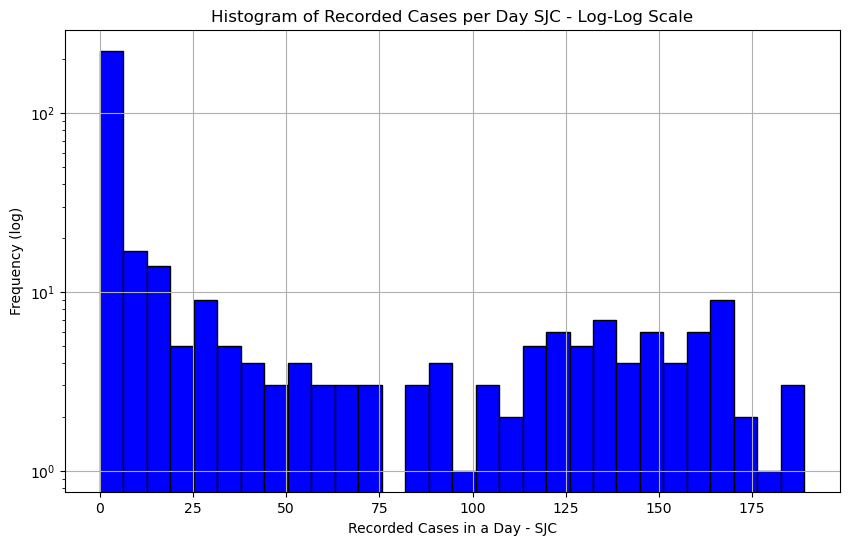

In [3]:
cases_filtered_by_date = cases
# Step 1: Sum the Values of All Columns for Each Day
soma_diaria = cases_filtered_by_date.sum(axis=1)

# Step 2: Plot the Histogram of Daily Sum with Log-Log Scale
plt.figure(figsize=(10, 6))
plt.hist(soma_diaria, bins=30, edgecolor='black', color='blue')

# OGet the Axes Object to Manipulate the Axes
ax = plt.gca()

ax.set_yscale('log')

plt.title('Histogram of Recorded Cases per Day SJC - Log-Log Scale')
plt.xlabel('Recorded Cases in a Day - SJC')
plt.ylabel('Frequency (log)')
plt.grid(True)
plt.show()

#### Histograms by ZT (Traffic Zones)

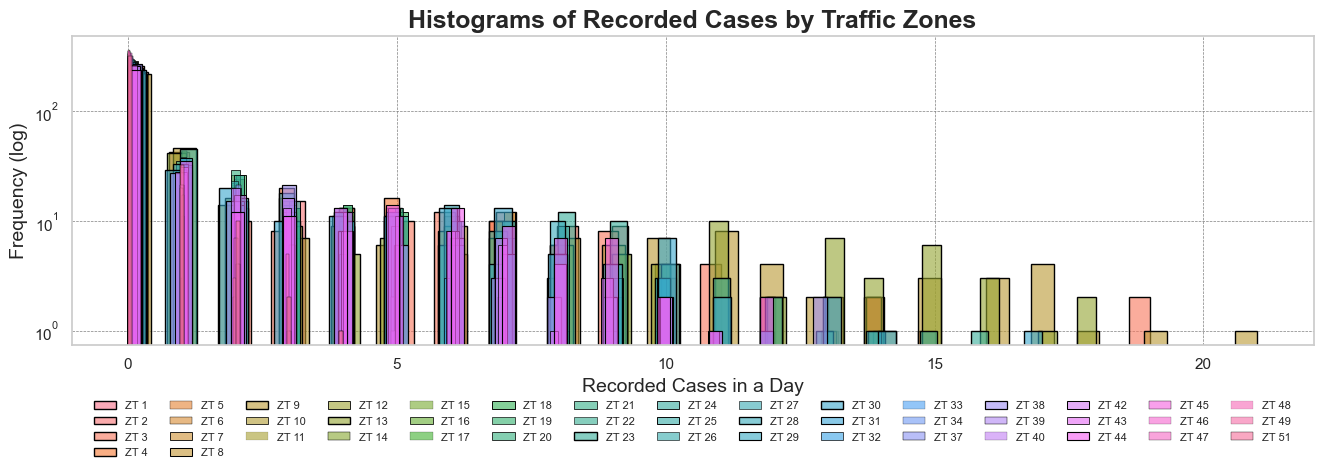

In [4]:
sns.set(style="whitegrid")

plt.figure(figsize=(14, 5))  # Aumente a largura do gráfico

num_columns = len(cases_filtered_by_date.columns)
if num_columns <= 20:
    colors = sns.color_palette("tab20", n_colors=num_columns)  # Usa a paleta tab20
else:
    colors = sns.color_palette("husl", n_colors=num_columns)  # Usa uma paleta que gera mais cores

for i, column in enumerate(cases_filtered_by_date.columns):
    sns.histplot(cases_filtered_by_date[column], bins=50, color=colors[i], label=f'ZT {column}', kde=False, alpha=0.6, edgecolor='black')

plt.title('Histograms of Recorded Cases by Traffic Zones', fontsize=18, weight='bold')
plt.xlabel('Recorded Cases in a Day', fontsize=14)
plt.ylabel('Frequency (log)', fontsize=14)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=15, fontsize=8, frameon=False)  # Ajuste ncol para o número de colunas desejado
plt.grid(color='gray', linestyle='--', linewidth=0.5)

ax = plt.gca()

ax.set_yscale('log')

plt.tight_layout()  
plt.show()


#### Checking ZTs with Few Recorded Values (Less than 4)

In [5]:
df = cases_filtered_by_date

# Step 1: Count How Many Days (Non-Zero Values) Each Column Had Recorded Cases
days_with_cases = df.apply(lambda col: (col != 0).sum())

# Step 2: Filter Columns with 4 or Fewer Days of Recorded Cases
columns_with_few_cases = days_with_cases[days_with_cases <= 4]

# Result: Display Columns with Up to 4 Days of Recorded Cases
limited_case_columns = columns_with_few_cases.index.tolist()
limited_case_counts = columns_with_few_cases.values

# Create a DataFrame to Display the Columns and the Day Count
result_df = pd.DataFrame({'Coluna': limited_case_columns, 'Dias com Casos Registrados': limited_case_counts})

print(result_df)

  Coluna  Dias com Casos Registrados
0     48                           3


#### Plotting the Number of Zeros per Day

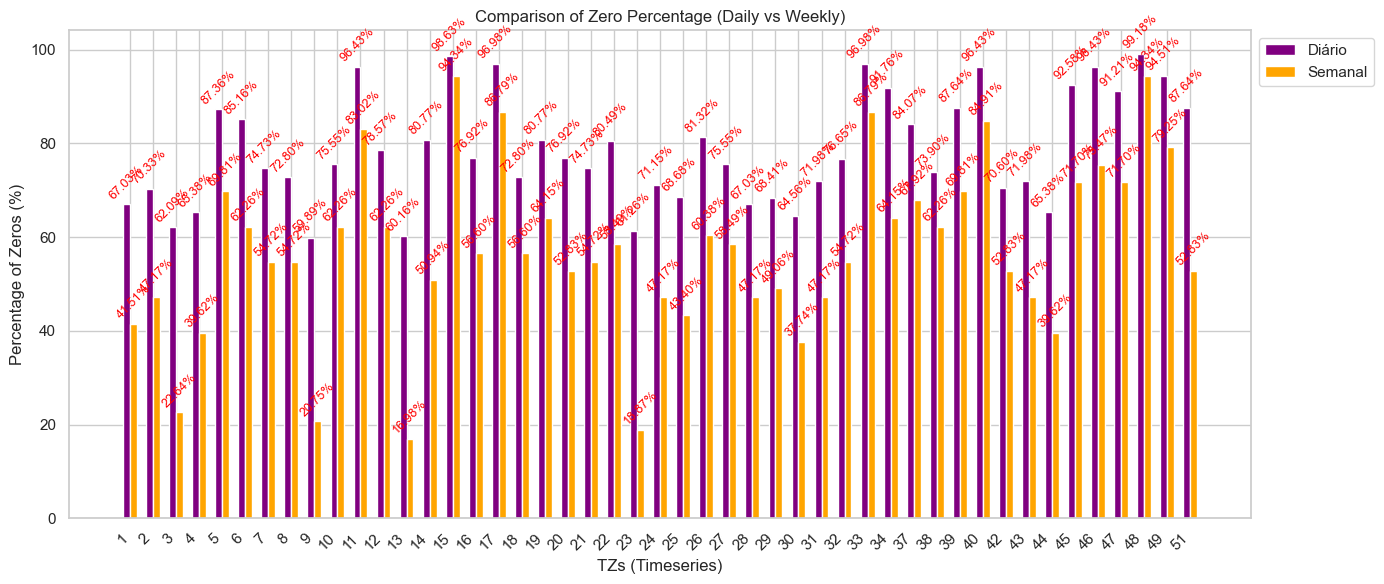

In [6]:
cases_filtered_by_date.index = pd.to_datetime(cases_filtered_by_date.index)

# Step 1: Calculate the Daily Percentage of Zeros
total_linhas_diario = cases_filtered_by_date.shape[0]
porcentagem_zeros_diario = (cases_filtered_by_date == 0).sum() / total_linhas_diario * 100

# Step 2: Group the Data by Week and Calculate the Weekly Percentage of Zeros
dados_semanais = cases_filtered_by_date.resample('W').sum()
total_linhas_semanal = dados_semanais.shape[0]
porcentagem_zeros_semanal = (dados_semanais == 0).sum() / total_linhas_semanal * 100

# Step 3: Create a Plot with Two Bars for Each Time Series (Daily and Weekly)
plt.figure(figsize=(14, 6))
largura_barra = 0.3 

# Generation of Daily Bars (to the left of each pair)
posicoes_diario = range(len(porcentagem_zeros_diario))
bars_diario = plt.bar([p - largura_barra/2 for p in posicoes_diario], porcentagem_zeros_diario.values, 
                      width=largura_barra, color='purple', label='Diário')

# Generation of Weekly Bars (to the right of each pair)
bars_semanal = plt.bar([p + largura_barra/2 for p in posicoes_diario], porcentagem_zeros_semanal.values, 
                       width=largura_barra, color='orange', label='Semanal')

# Step 4: Add Values Above the Bars with Smaller Font, White Color, and Tilted Angle
for bar in bars_diario + bars_semanal:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.2f}%', 
             ha='center', va='bottom', rotation=45, fontsize=9, color='red') 

plt.title('Comparison of Zero Percentage (Daily vs Weekly)')
plt.xlabel('TZs (Timeseries)')
plt.ylabel('Percentage of Zeros (%)')

plt.xticks([p for p in posicoes_diario], porcentagem_zeros_diario.index, rotation=45, ha='right')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout() 
plt.show()


#### Plotting Time Series Without Zeros for Each Date

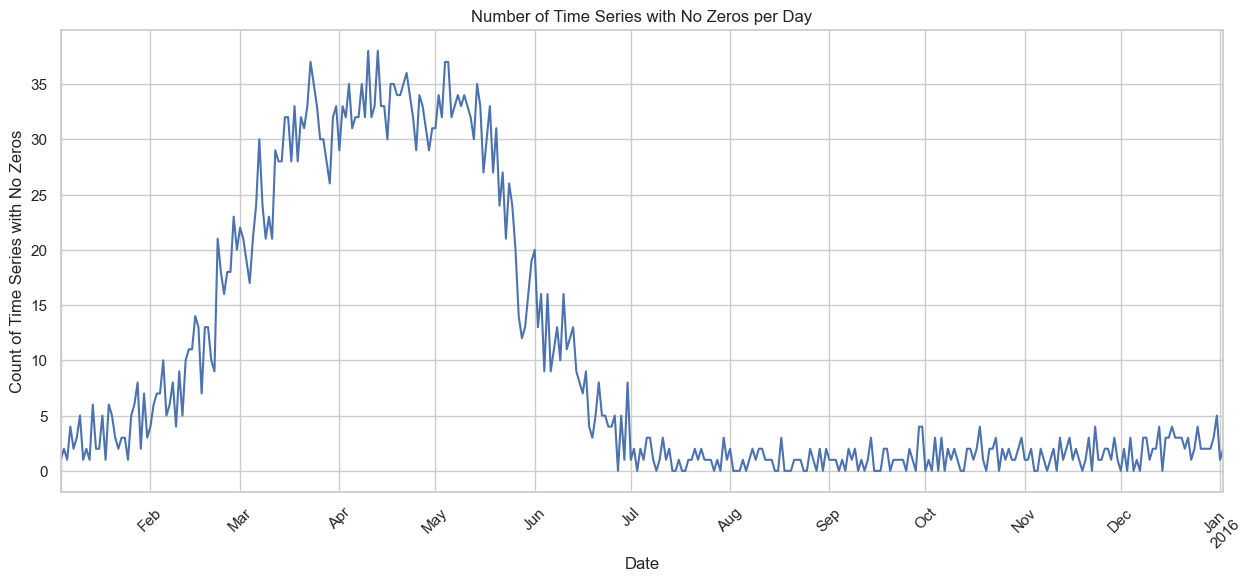

In [7]:
# Step 1: Check, for each day, how many columns have non-zero values.
non_zero_count = (cases_filtered_by_date != 0).sum(axis=1)

plt.figure(figsize=(15, 6))
non_zero_count.plot()
plt.title('Number of Time Series with No Zeros per Day')
plt.xlabel('Date')
plt.ylabel('Count of Time Series with No Zeros')
plt.grid(True)
plt.xticks(rotation=45) 
plt.show()

#### Plotting Bar Chart (Weekly Cases)

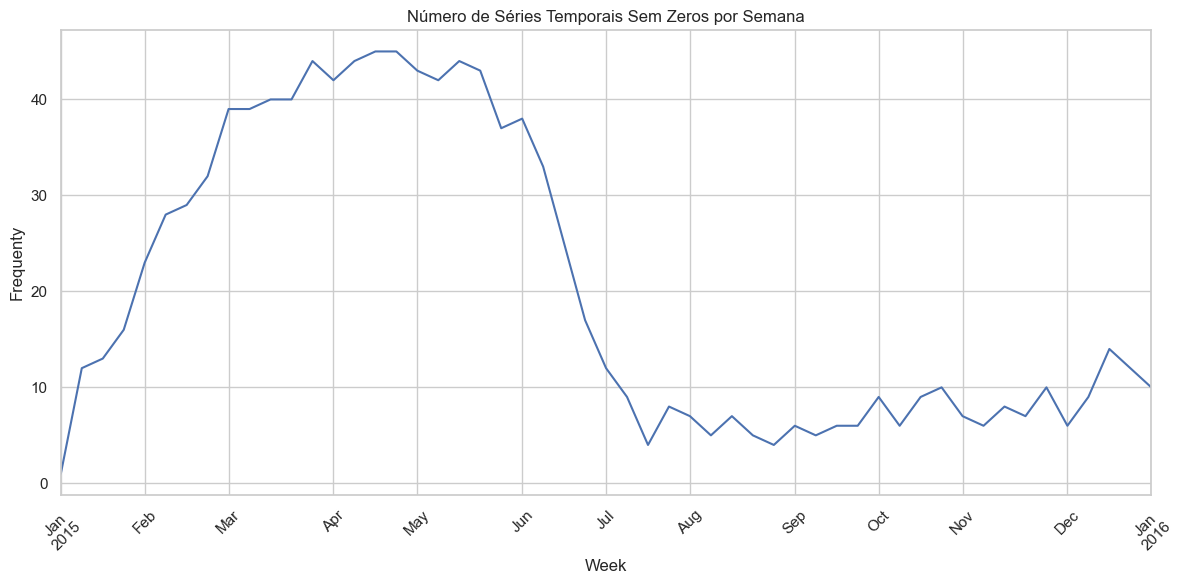

In [8]:
df = cases_filtered_by_date
df.index = pd.to_datetime(df.index)

# Step 1: Group the Data by Weeks (Resample)
weekly_non_zero_count = (df != 0).resample('W').sum()

# Step 2: Count How Many Columns Have Non-Zero Values for Each Week
weekly_non_zero_count_summary = (weekly_non_zero_count > 0).sum(axis=1)

plt.figure(figsize=(12, 6))
weekly_non_zero_count_summary.plot()
plt.title('Número de Séries Temporais Sem Zeros por Semana')
plt.xlabel('Week')
plt.ylabel('Frequenty')
plt.grid(True)
plt.xticks(rotation=45)  # Rotacionar os rótulos no eixo X para melhor legibilidade
plt.tight_layout()  # Ajustar o layout
plt.show()

In [9]:
# Group the DataFrame Every 7 Rows Based on Position (Using Integer Division by 7)
cases_filtered_by_date['semana_epi'] = (cases_filtered_by_date.reset_index().index // 7) + 1

# Group by the label 'semana_epi' and sum the values.
df_semanal = cases_filtered_by_date.groupby('semana_epi').sum()

columns_to_drop = ['semana_epi']
cases_filtered_by_date = cases_filtered_by_date.drop(columns=columns_to_drop)
df_semanal

,1,2,3,4,5,6,7,8,9,10,...,40,42,43,44,45,46,47,48,49,51
semana_epi,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,0,0,0,0,0,3,0,...,0,0,2,0,0,0,0,0,0,1
2,0,1,2,1,0,0,2,0,1,0,...,0,1,1,0,0,0,0,0,0,5
3,0,1,0,1,0,1,0,0,1,0,...,0,0,0,4,0,0,0,0,0,0
4,0,2,1,2,0,1,4,3,1,0,...,0,0,1,0,0,0,0,0,0,2
5,5,5,6,1,0,1,1,0,1,1,...,0,3,1,3,1,0,0,0,0,0
6,7,5,6,9,2,0,1,1,2,1,...,0,2,4,8,0,1,0,0,0,0
7,22,6,20,24,0,0,4,1,11,3,...,0,0,3,5,2,0,0,0,1,0
8,16,24,19,22,4,2,5,5,5,4,...,0,8,1,15,0,1,1,0,0,1
9,36,16,32,21,2,2,4,10,22,9,...,0,12,9,19,4,2,0,0,1,1


In [10]:
df_semanal.to_csv('data/semanal_2015.csv')

In [11]:
print(df_semanal.index)
start_date = '2015-01-04' 
date_rng = pd.date_range(start=start_date, periods=len(df_semanal), freq='W')
df_semanal.index = date_rng
df_semanal

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52],
      dtype='int64', name='semana_epi')


,1,2,3,4,5,6,7,8,9,10,...,40,42,43,44,45,46,47,48,49,51
2015-01-04,1,1,0,0,0,0,0,0,3,0,...,0,0,2,0,0,0,0,0,0,1
2015-01-11,0,1,2,1,0,0,2,0,1,0,...,0,1,1,0,0,0,0,0,0,5
2015-01-18,0,1,0,1,0,1,0,0,1,0,...,0,0,0,4,0,0,0,0,0,0
2015-01-25,0,2,1,2,0,1,4,3,1,0,...,0,0,1,0,0,0,0,0,0,2
2015-02-01,5,5,6,1,0,1,1,0,1,1,...,0,3,1,3,1,0,0,0,0,0
2015-02-08,7,5,6,9,2,0,1,1,2,1,...,0,2,4,8,0,1,0,0,0,0
2015-02-15,22,6,20,24,0,0,4,1,11,3,...,0,0,3,5,2,0,0,0,1,0
2015-02-22,16,24,19,22,4,2,5,5,5,4,...,0,8,1,15,0,1,1,0,0,1
2015-03-01,36,16,32,21,2,2,4,10,22,9,...,0,12,9,19,4,2,0,0,1,1
2015-03-08,45,23,48,51,7,3,5,7,26,11,...,0,17,22,24,2,0,5,0,0,1


#### Plotting the Percentage of Zeros per TZs

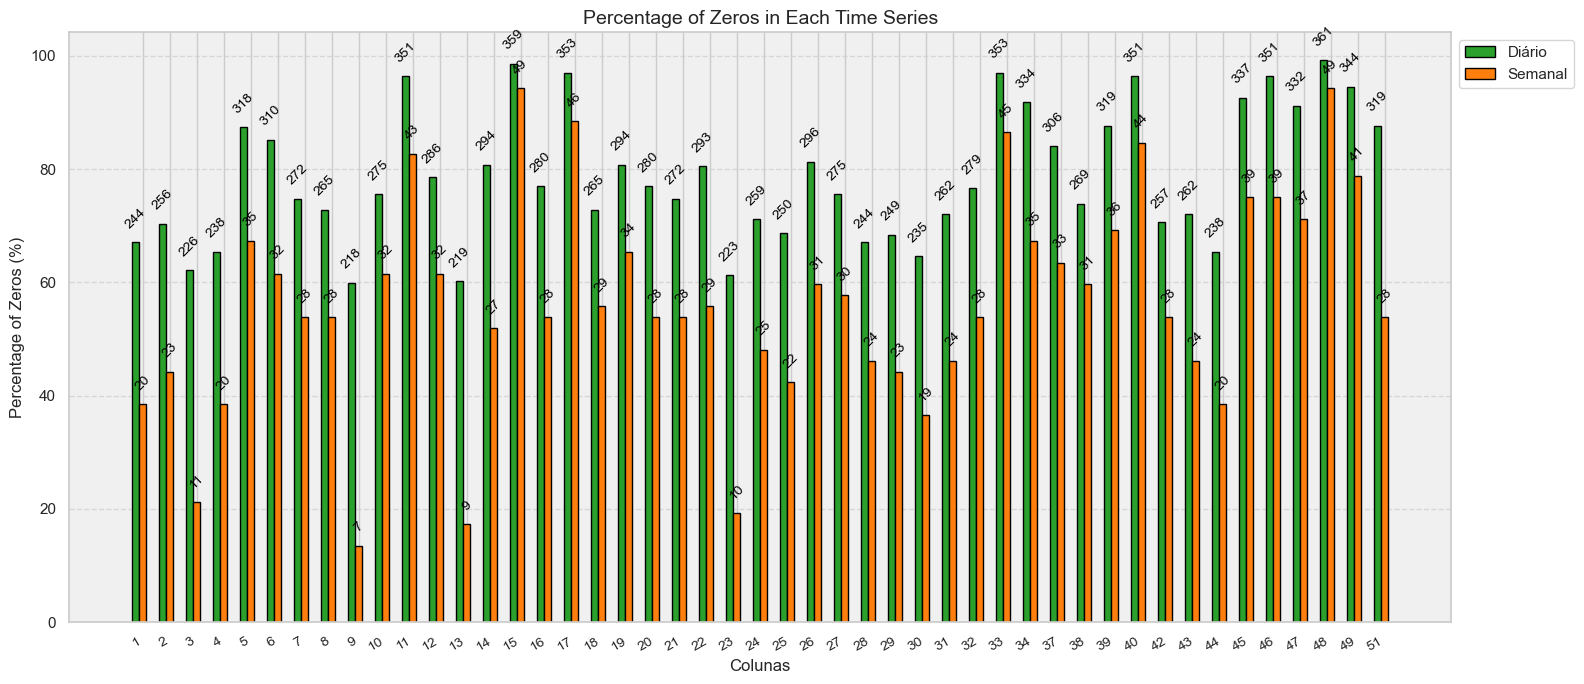

In [12]:
# Function to Calculate Zeros and Percentage
def calculate_zeros_and_percentage(df):
    zeros_count = (df == 0).sum()
    total_count = len(df)  # Total de linhas no DataFrame
    percentage_zeros = (zeros_count / total_count) * 100
    return zeros_count, percentage_zeros

# Calculate for both DataFrames independently
zeros_count_df1, percentage_zeros_df1 = calculate_zeros_and_percentage(cases_filtered_by_date)
zeros_count_df2, percentage_zeros_df2 = calculate_zeros_and_percentage(df_semanal)

# Define the Bar Width and Spacing
bar_width = 0.35 
spacing = 1  
index = np.arange(len(zeros_count_df1)) * (bar_width + spacing) # Adjust the Position of the Bars

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(index, percentage_zeros_df1, bar_width, label='Diário', color='#2ca02c', edgecolor='black')

bars2 = ax.bar(index + bar_width, percentage_zeros_df2, bar_width, label='Semanal', color='#ff7f0e', edgecolor='black')

for i, bar in enumerate(bars1):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2,
            str(int(zeros_count_df1.iloc[i])), 
            ha='center', va='bottom', fontsize=10, color='black', rotation=45)

for i, bar in enumerate(bars2):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2,
            str(int(zeros_count_df2.iloc[i])), 
            ha='center', va='bottom', fontsize=10, color='black', rotation=45)

ax.set_title('Percentage of Zeros in Each Time Series', fontsize=14)
ax.set_xlabel('Colunas', fontsize=12)
ax.set_ylabel('Percentage of Zeros (%)', fontsize=12)
ax.set_xticks(index + bar_width)  # Ajustar as posições dos rótulos no eixo x
ax.set_xticklabels(zeros_count_df1.index, rotation=30, ha='right', fontsize=10)  # Inclinar rótulos para 30 graus
ax.legend(fontsize=12)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)  # Grade horizontal

ax.set_facecolor('#f0f0f0')  # Fundo claro para destacar as barras

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


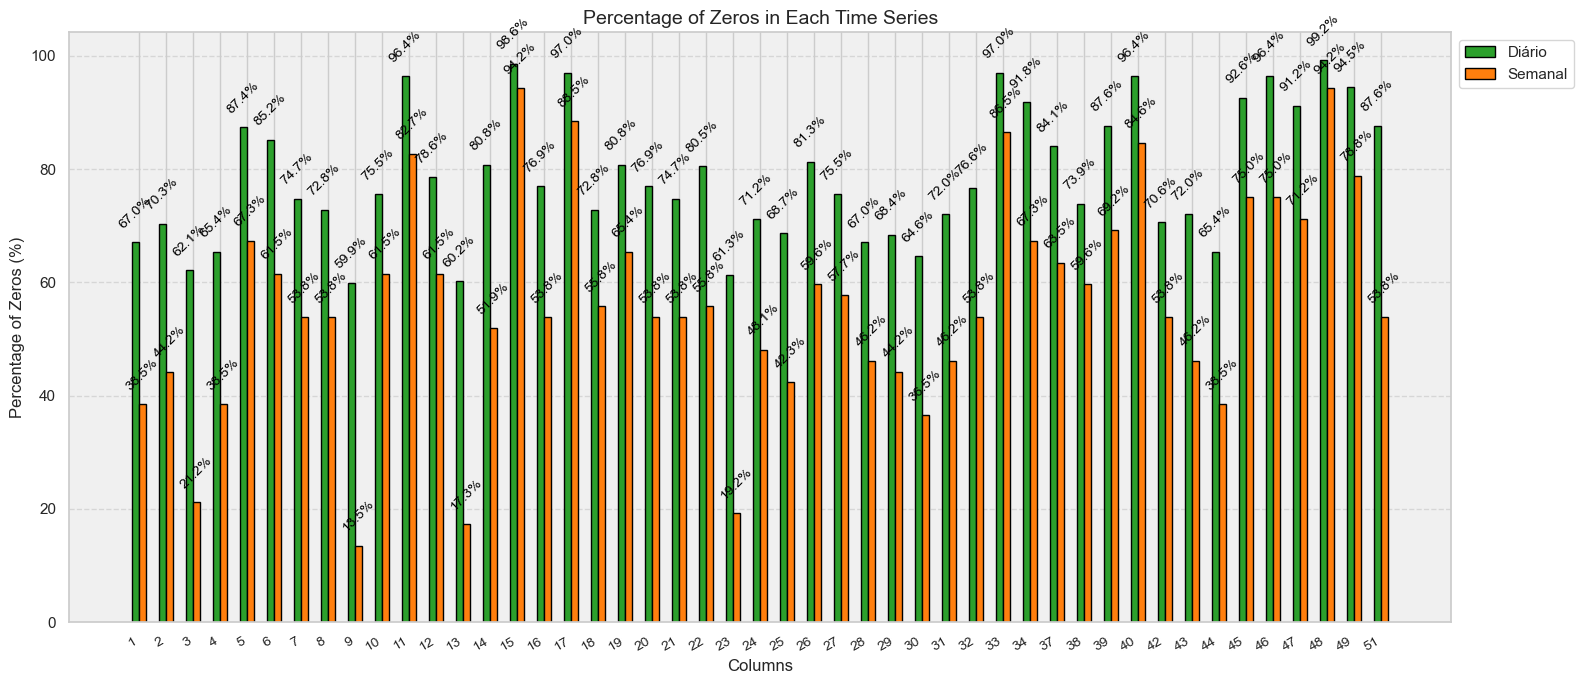

In [13]:
def calculate_zeros_and_percentage(df):
    zeros_count = (df == 0).sum()
    total_count = len(df) 
    percentage_zeros = (zeros_count / total_count) * 100
    return zeros_count, percentage_zeros

zeros_count_df1, percentage_zeros_df1 = calculate_zeros_and_percentage(cases_filtered_by_date)
zeros_count_df2, percentage_zeros_df2 = calculate_zeros_and_percentage(df_semanal)

bar_width = 0.35 
spacing = 1
index = np.arange(len(zeros_count_df1)) * (bar_width + spacing) 

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(index, percentage_zeros_df1, bar_width, label='Diário', color='#2ca02c', edgecolor='black')

bars2 = ax.bar(index + bar_width, percentage_zeros_df2, bar_width, label='Semanal', color='#ff7f0e', edgecolor='black')

for i, bar in enumerate(bars1):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2,
            f'{percentage_zeros_df1.iloc[i]:.1f}%',
            ha='center', va='bottom', fontsize=10, color='black', rotation=45)

for i, bar in enumerate(bars2):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2,
            f'{percentage_zeros_df2.iloc[i]:.1f}%',
            ha='center', va='bottom', fontsize=10, color='black', rotation=45)

ax.set_title('Percentage of Zeros in Each Time Series', fontsize=14)
ax.set_xlabel('Columns', fontsize=12)
ax.set_ylabel('Percentage of Zeros (%)', fontsize=12)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(zeros_count_df1.index, rotation=30, ha='right', fontsize=10)
ax.legend(fontsize=12)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

ax.set_facecolor('#f0f0f0')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


#### Considering the graphs above, we decided to work with weekly data.

Histogram of Weekly Cases

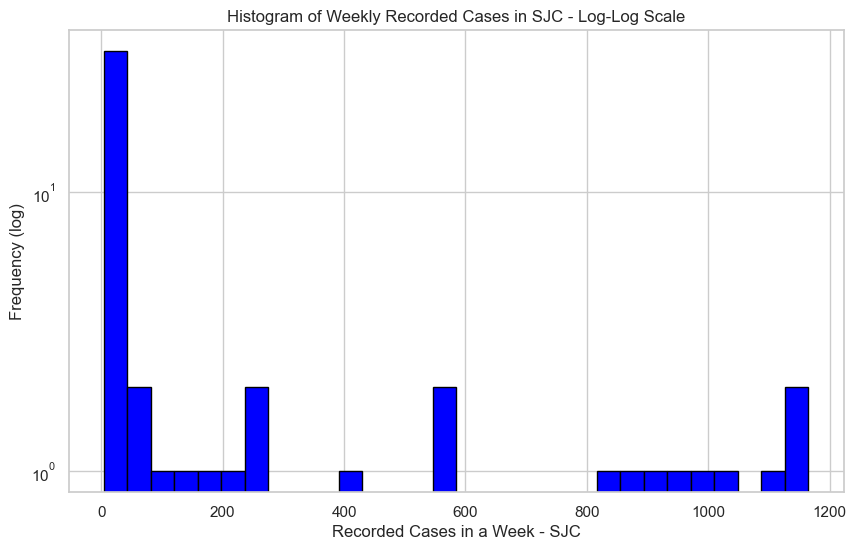

In [14]:
soma_semanal = df_semanal.sum(axis=1)

plt.figure(figsize=(10, 6))
plt.hist(soma_semanal, bins=30, edgecolor='black', color='blue')

ax = plt.gca()

ax.set_yscale('log')

plt.title('Histogram of Weekly Recorded Cases in SJC - Log-Log Scale')
plt.xlabel('Recorded Cases in a Week - SJC')
plt.ylabel('Frequency (log)')
plt.grid(True)
plt.show()

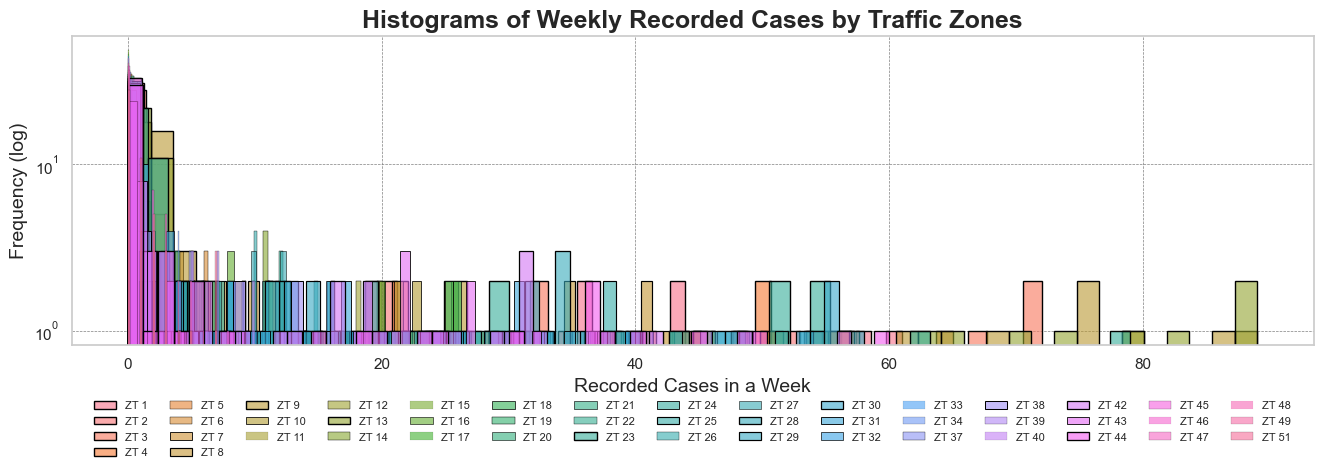

In [15]:
sns.set(style="whitegrid")

plt.figure(figsize=(14, 5))  # Aumente a largura do gráfico

num_columns = len(df_semanal.columns)
if num_columns <= 20:
    colors = sns.color_palette("tab20", n_colors=num_columns)  # Usa a paleta tab20
else:
    colors = sns.color_palette("husl", n_colors=num_columns)  # Usa uma paleta que gera mais cores

for i, column in enumerate(df_semanal.columns):
    sns.histplot(df_semanal[column], bins=50, color=colors[i], label=f'ZT {column}', kde=False, alpha=0.6, edgecolor='black')

plt.title('Histograms of Weekly Recorded Cases by Traffic Zones', fontsize=18, weight='bold')
plt.xlabel('Recorded Cases in a Week', fontsize=14)
plt.ylabel('Frequency (log)', fontsize=14)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=15, fontsize=8, frameon=False)  # Ajuste ncol para o número de colunas desejado
plt.grid(color='gray', linestyle='--', linewidth=0.5)

ax = plt.gca()
ax.set_yscale('log')

plt.tight_layout()
plt.show()


#### Calculating Similarity Matrix with Mutual Information

In [16]:
n = df_semanal.shape[1]
matriz_similaridade_inform_mutua = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            matriz_similaridade_inform_mutua[i, j] = 1.0 
        else:
            info_mutua = mutual_info_regression(df_semanal[[df_semanal.columns[i]]], df_semanal[df_semanal.columns[j]],random_state=42)  # Fixando o random_state para consistência)
            matriz_similaridade_inform_mutua[i, j] = info_mutua[0]

matriz_similaridade_df = pd.DataFrame(matriz_similaridade_inform_mutua, index=df_semanal.columns, columns=df_semanal.columns)

print("Similarity Matrix (Mutual Information):")
matriz_similaridade_df

Similarity Matrix (Mutual Information):


,1,2,3,4,5,6,7,8,9,10,...,40,42,43,44,45,46,47,48,49,51
1,1.000000,0.336794,0.565065,0.635834,0.210062,0.231241,0.286893,0.255507,0.183230,0.275626,...,0.094385,0.336337,0.254972,0.268289,0.325170,0.052719,0.254294,0.000000,0.168031,0.004604
2,0.441903,1.000000,0.507982,0.594110,0.377482,0.429704,0.374320,0.258945,0.158562,0.286282,...,0.072302,0.443751,0.260484,0.457028,0.206370,0.234240,0.286278,0.020410,0.148683,0.012536
3,0.526039,0.457575,1.000000,0.564924,0.304358,0.384684,0.447871,0.363447,0.308044,0.326478,...,0.144133,0.477951,0.375917,0.371733,0.244015,0.124355,0.393781,0.074383,0.204457,0.057623
4,0.721088,0.508158,0.629607,1.000000,0.368378,0.298210,0.308838,0.245121,0.178637,0.272804,...,0.041090,0.334461,0.225853,0.269330,0.215244,0.097853,0.267384,0.000000,0.147063,0.000000
5,0.229346,0.274948,0.227467,0.384370,1.000000,0.258008,0.220814,0.093478,0.092501,0.196765,...,0.094310,0.233716,0.123074,0.127523,0.247991,0.164341,0.221438,0.061964,0.092119,0.136065
6,0.201741,0.248487,0.234140,0.330686,0.250359,1.000000,0.367106,0.255235,0.370982,0.341043,...,0.156586,0.370388,0.261695,0.320029,0.181087,0.043553,0.289883,0.077694,0.222624,0.161439
7,0.285496,0.286188,0.324597,0.395190,0.233272,0.216484,1.000000,0.324605,0.194266,0.278567,...,0.091415,0.430675,0.293540,0.225177,0.182867,0.111035,0.293975,0.018565,0.109012,0.056497
8,0.315013,0.320816,0.344840,0.457283,0.134161,0.334640,0.379623,1.000000,0.252263,0.328817,...,0.096665,0.443513,0.275201,0.262461,0.207742,0.044923,0.280289,0.052218,0.126609,0.062136
9,0.291029,0.336160,0.319676,0.443440,0.311998,0.430514,0.467761,0.408423,1.000000,0.452739,...,0.147101,0.507993,0.356972,0.361964,0.227091,0.053183,0.406135,0.051692,0.207150,0.169728
10,0.319089,0.354679,0.369778,0.434024,0.331513,0.363884,0.406706,0.403423,0.466421,1.000000,...,0.139183,0.554398,0.431034,0.487954,0.300735,0.021994,0.494019,0.034601,0.311087,0.135178


In [17]:
matriz_similaridade_df.to_csv('data/weeklycases_mutualinformation.csv')

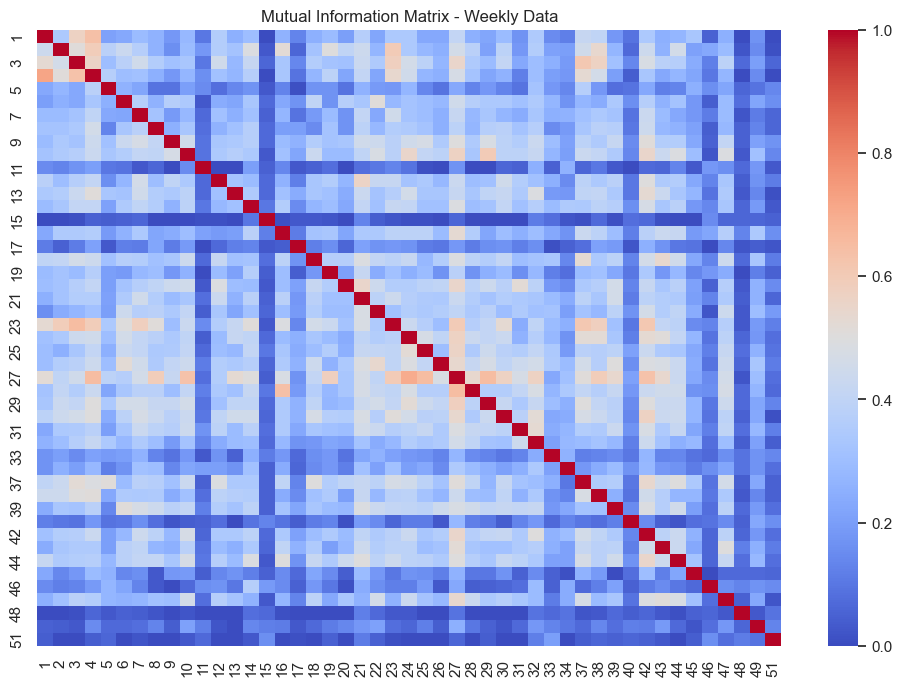

In [18]:
pd.set_option('display.max_columns', None)
informacao_mutua_semanal = matriz_similaridade_df.round(2)
informacao_mutua_semanal

plt.figure(figsize=(12, 8))
sns.heatmap(informacao_mutua_semanal, cmap='coolwarm', cbar=True)
plt.title('Mutual Information Matrix - Weekly Data')
plt.show()

#### Histogram of Mutual Information Values Calculated Between Pairs of Time Series from ZTs

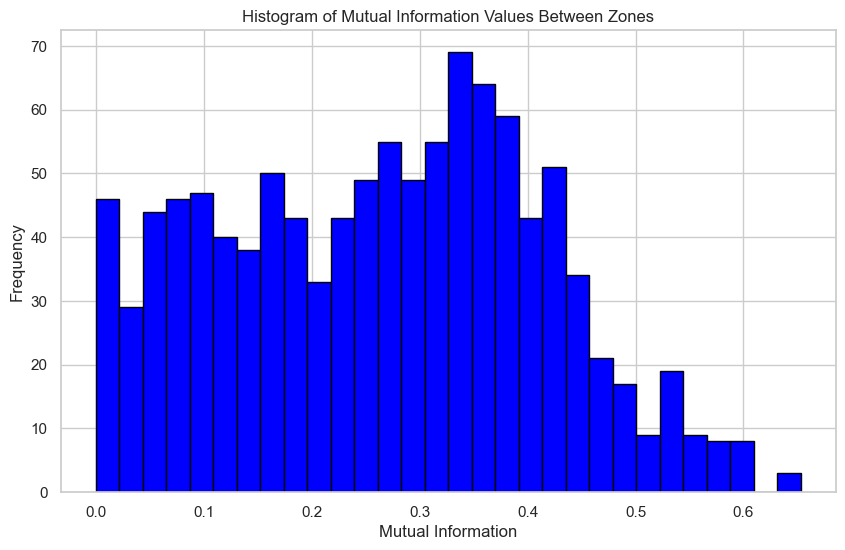

In [19]:
# Step 1: Extract the Values from the Upper Part of the Similarity Matrix
valores_inform_mutua = matriz_similaridade_df.values
valores_superior = valores_inform_mutua[np.triu_indices(n, k=1)]  # k=1 para ignorar a diagonal

# Step 2: Plot the Histogram of Mutual Information Values
plt.figure(figsize=(10, 6))
plt.hist(valores_superior, bins=30, color='blue', edgecolor='black')
plt.title('Histogram of Mutual Information Values Between Zones')
plt.xlabel('Mutual Information')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()